# Task 2 — Basic scRNA-seq Tutorial

**Reference:** [Scanpy Basic scRNA-seq Tutorial](https://github.com/scverse/scanpy-tutorials/blob/main/basic-scrna-tutorial.ipynb)

**Dataset:** PBMC 3K (pre-processed in Task 1)  
**Tools:** Scanpy, Leiden algorithm, UMAP

---

## Step 0 — Install & Import Libraries

In [2]:
# !pip install scanpy leidenalg matplotlib seaborn
!pip install scanpy
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white', figsize=(7, 5))

print('Scanpy version:', sc.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 84.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.

## Step 1 — Load Pre-processed Data

In [3]:
import os

# Try to load pre-processed data from Task 1; if not found, rerun preprocessing
if os.path.exists('../01-preprocessing/pbmc3k_preprocessed.h5ad'):
    adata = sc.read_h5ad('../01-preprocessing/pbmc3k_preprocessed.h5ad')
    print('Loaded pre-processed data from Task 1.')
else:
    print('Pre-processed file not found. Regenerating from scratch...')
    adata = sc.datasets.pbmc3k_processed()
    print('Loaded processed PBMC 3K from Scanpy datasets.')

print(adata)

Pre-processed file not found. Regenerating from scratch...
try downloading from url
https://exampledata.scverse.org/scanpy/pbmc3k.h5ad
... this may take a while but only happens once


  0%|          | 0.00/23.5M [00:00<?, ?B/s]

Loaded processed PBMC 3K from Scanpy datasets.
AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


## Step 2 — Compute Neighborhood Graph

This command constructs a graph where each cell is connected to its 10 most similar cells based on their 40 principal components. This connectivity map serves as the foundation for downstream tasks like clustering, pseudotime analysis, and visualization.

In [4]:
# Build k-nearest neighbor graph using PCA coordinates
# n_neighbors=10, n_pcs=40 are standard parameters for PBMC data
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
print('Neighborhood graph computed.')

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:43)
Neighborhood graph computed.


## Step 3 — Compute UMAP Embedding

This code executes the Uniform Manifold Approximation and Projection (UMAP) algorithm to reduce your high-dimensional single-cell data into a 2D space for visualization. The result is stored in adata.obsm['X_umap'] as a matrix of shape $(N \times 2)$, where $N$ is the number of cells.

In [5]:
sc.tl.umap(adata)
print('UMAP embedding computed.')
print(f'UMAP shape: {adata.obsm["X_umap"].shape}')

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)
UMAP embedding computed.
UMAP shape: (2638, 2)


## Step 4 — Leiden Clustering

This code installs the necessary clustering library and then partitions cells into groups based on their neighborhood similarities, with the resolution parameter determining the final number of clusters. It concludes by calculating and printing the total number of clusters found along with the distribution of cells across each group.

In [8]:
# Leiden clustering — resolution controls granularity (higher = more clusters)
!pip install leidenalg
sc.tl.leiden(adata, resolution=0.5)

n_clusters = adata.obs['leiden'].nunique()
print(f'Number of Leiden clusters: {n_clusters}')
print('Cluster sizes:')
print(adata.obs['leiden'].value_counts().sort_index())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 106.3 MB/s eta 0:00:00
running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
Number of Leiden clusters: 6
Cluster sizes:
leiden
0    1175
1     638
2     440
3     341
4      31
5      13
Name: count, dtype: int64


## Step 5 — Visualize UMAP Colored by Cluster

This code generates a UMAP visualization where your cells are color-coded by their assigned Leiden cluster, with labels placed directly on the plot for easy identification. The parameters frameon=False and save ensure a clean, borderless aesthetic and export the figure as a PNG file.

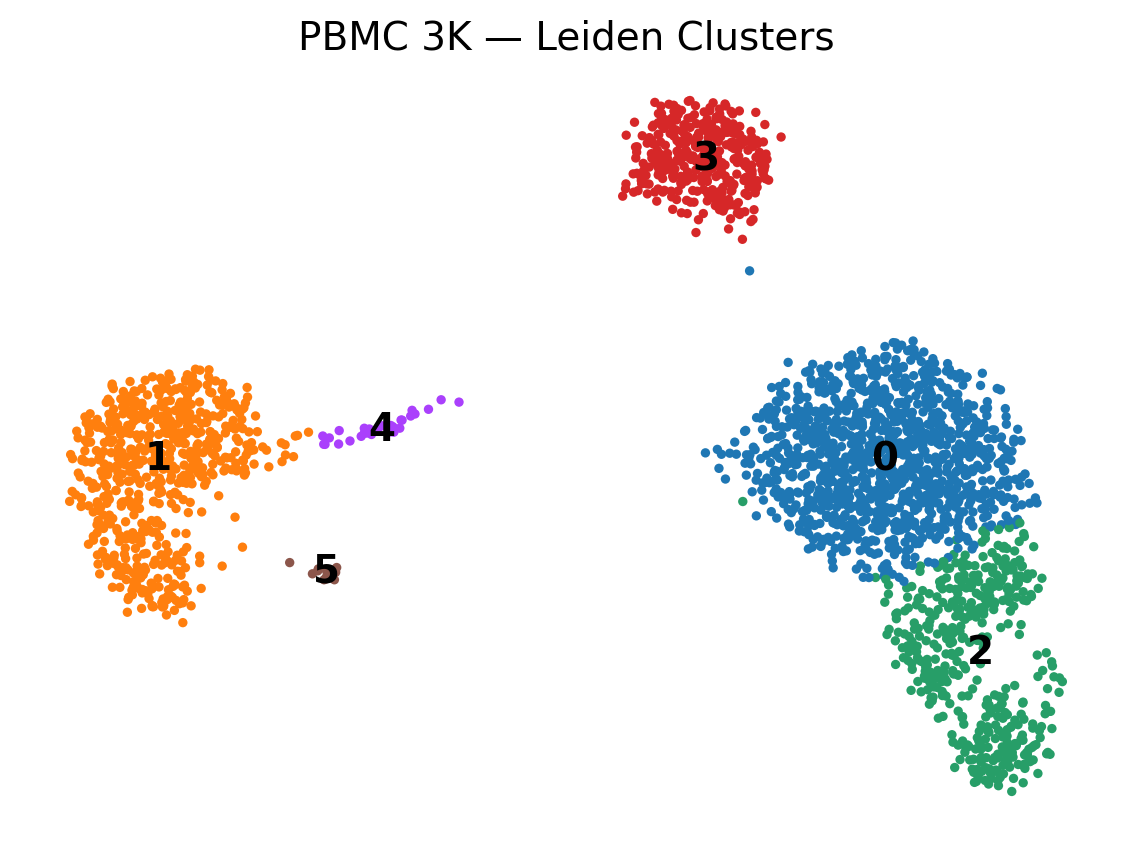

UMAP cluster plot saved.


In [9]:
sc.pl.umap(
    adata,
    color=['leiden'],
    legend_loc='on data',
    title='PBMC 3K — Leiden Clusters',
    frameon=False,
    save='_leiden_clusters.png'
)
print('UMAP cluster plot saved.')

## Step 6 — Find Marker Genes per Cluster

This code identifies marker genes for each cluster by statistically testing which genes are significantly more expressed in a specific cluster compared to all others using the Wilcoxon rank-sum test. It then visualizes the top 10 most differentially expressed genes for each cluster in a ranked plot and saves the output as an image.

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:13)


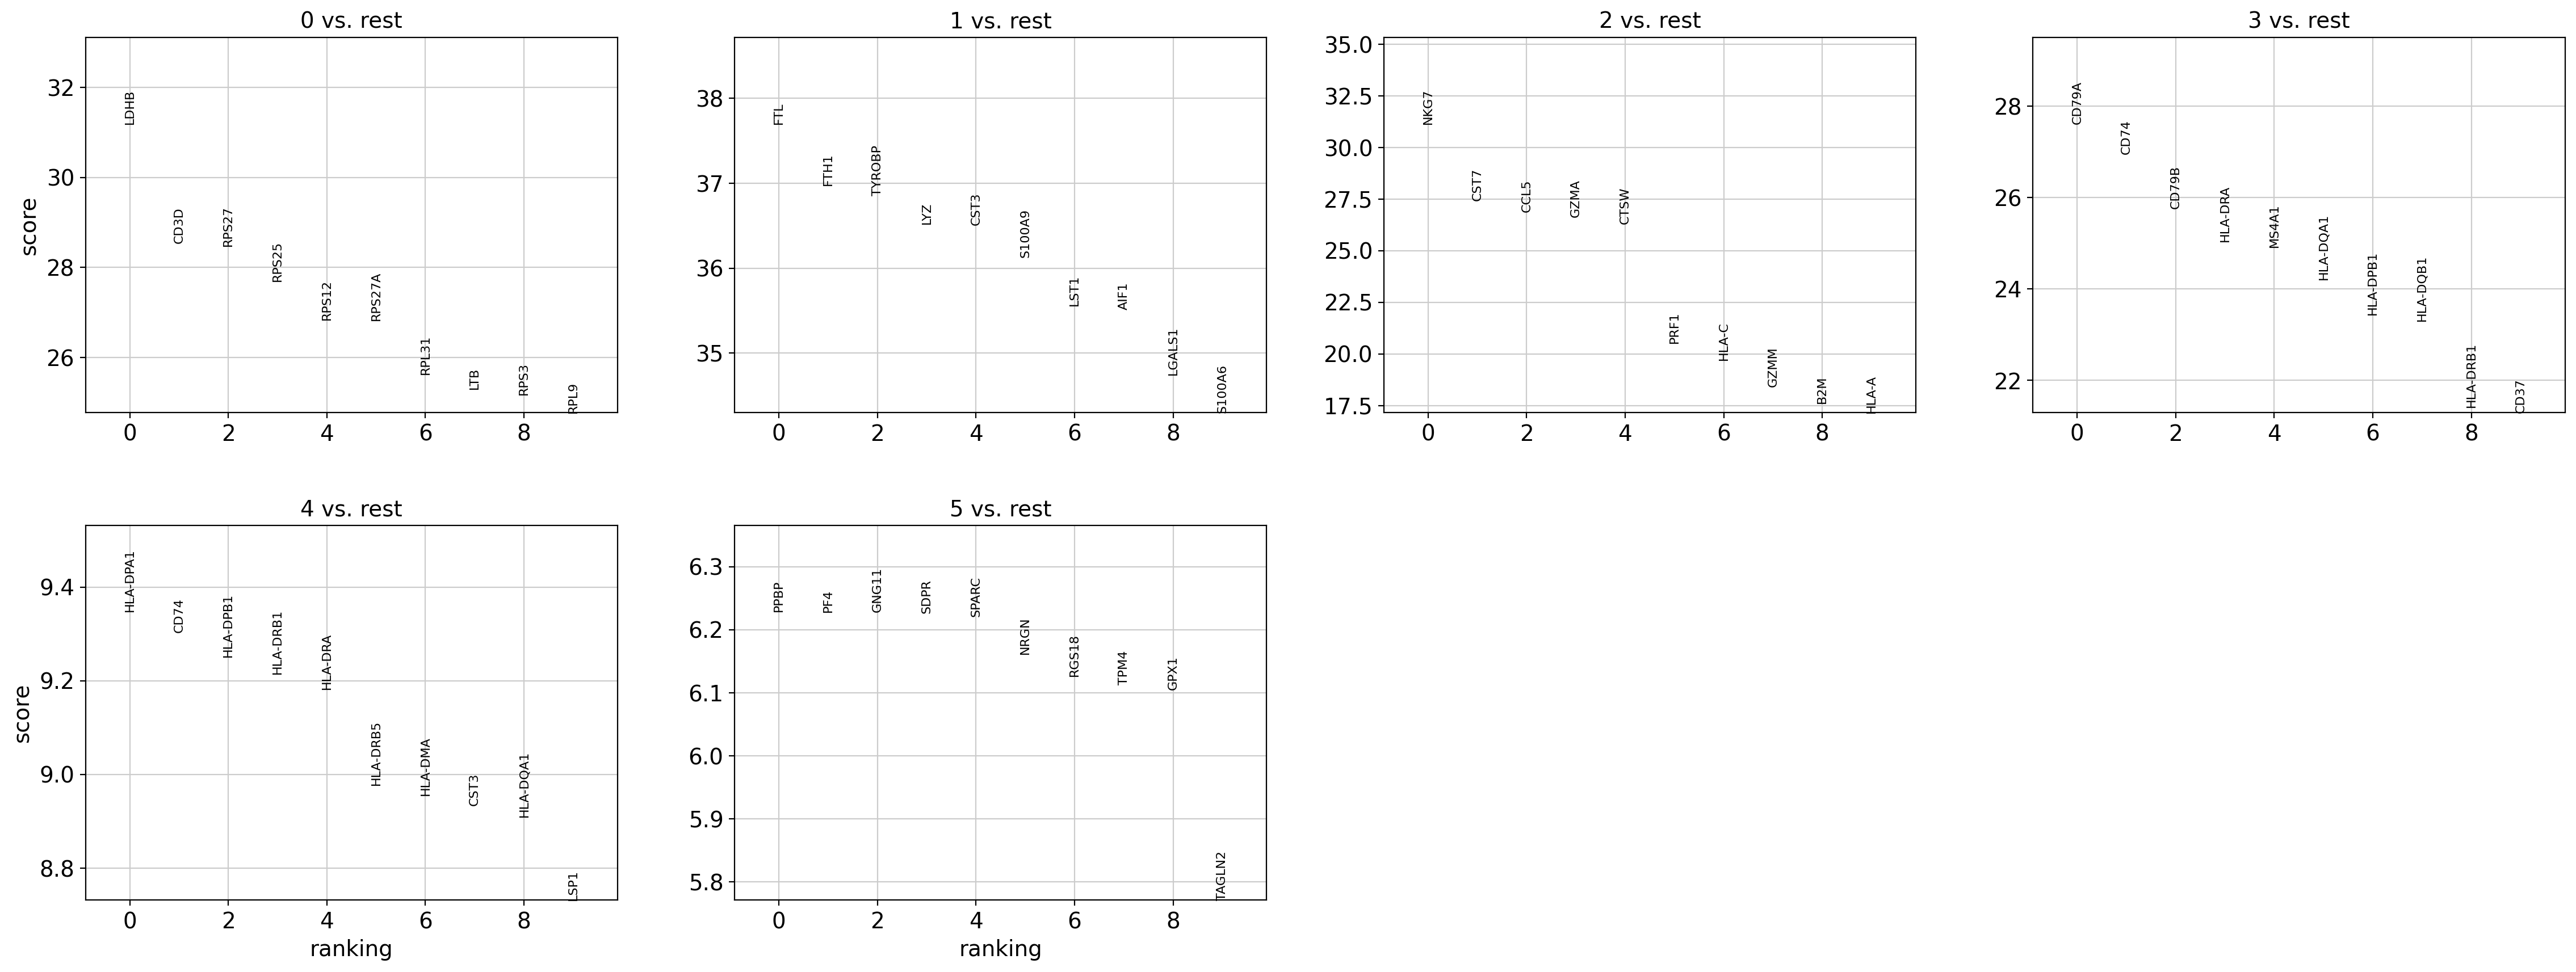

Marker genes calculated and plotted.


In [10]:
# Rank genes for each cluster using the Wilcoxon rank-sum test
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False, save='_rank_genes.png')
print('Marker genes calculated and plotted.')

This code extracts the ranked gene results from the adata object and organizes the top 5 marker genes for each cluster into a structured pandas DataFrame for easy inspection. It effectively turns the statistical output of the Wilcoxon test into a readable table, allowing you to quickly identify the key genes that define each cell population.

In [11]:
# Show top 5 marker genes per cluster as a table
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
top_markers = pd.DataFrame(
    {group: result['names'][group][:5] for group in groups}
)
print('Top 5 marker genes per cluster:')
print(top_markers)

Top 5 marker genes per cluster:
       0       1     2        3         4      5
0   LDHB     FTL  NKG7    CD79A  HLA-DPA1   PPBP
1   CD3D    FTH1  CST7     CD74      CD74    PF4
2  RPS27  TYROBP  CCL5    CD79B  HLA-DPB1  GNG11
3  RPS25     LYZ  GZMA  HLA-DRA  HLA-DRB1   SDPR
4  RPS12    CST3  CTSW    MS4A1   HLA-DRA  SPARC


## Step 7 — Visualize Known Cell-Type Marker Genes on UMAP

This code visualizes the expression of specific PBMC cell-type markers across your UMAP projection, allowing you to manually confirm the biological identity of your clusters. It filters the requested list to ensure only genes present in your data are plotted and then generates a grid of UMAP plots, with each gene colored by its normalized expression level.

By observing where these marker genes "light up" on the UMAP, you can effectively match your clusters to known cell populations (e.g., confirming that a cluster expressing MS4A1 corresponds to B cells).

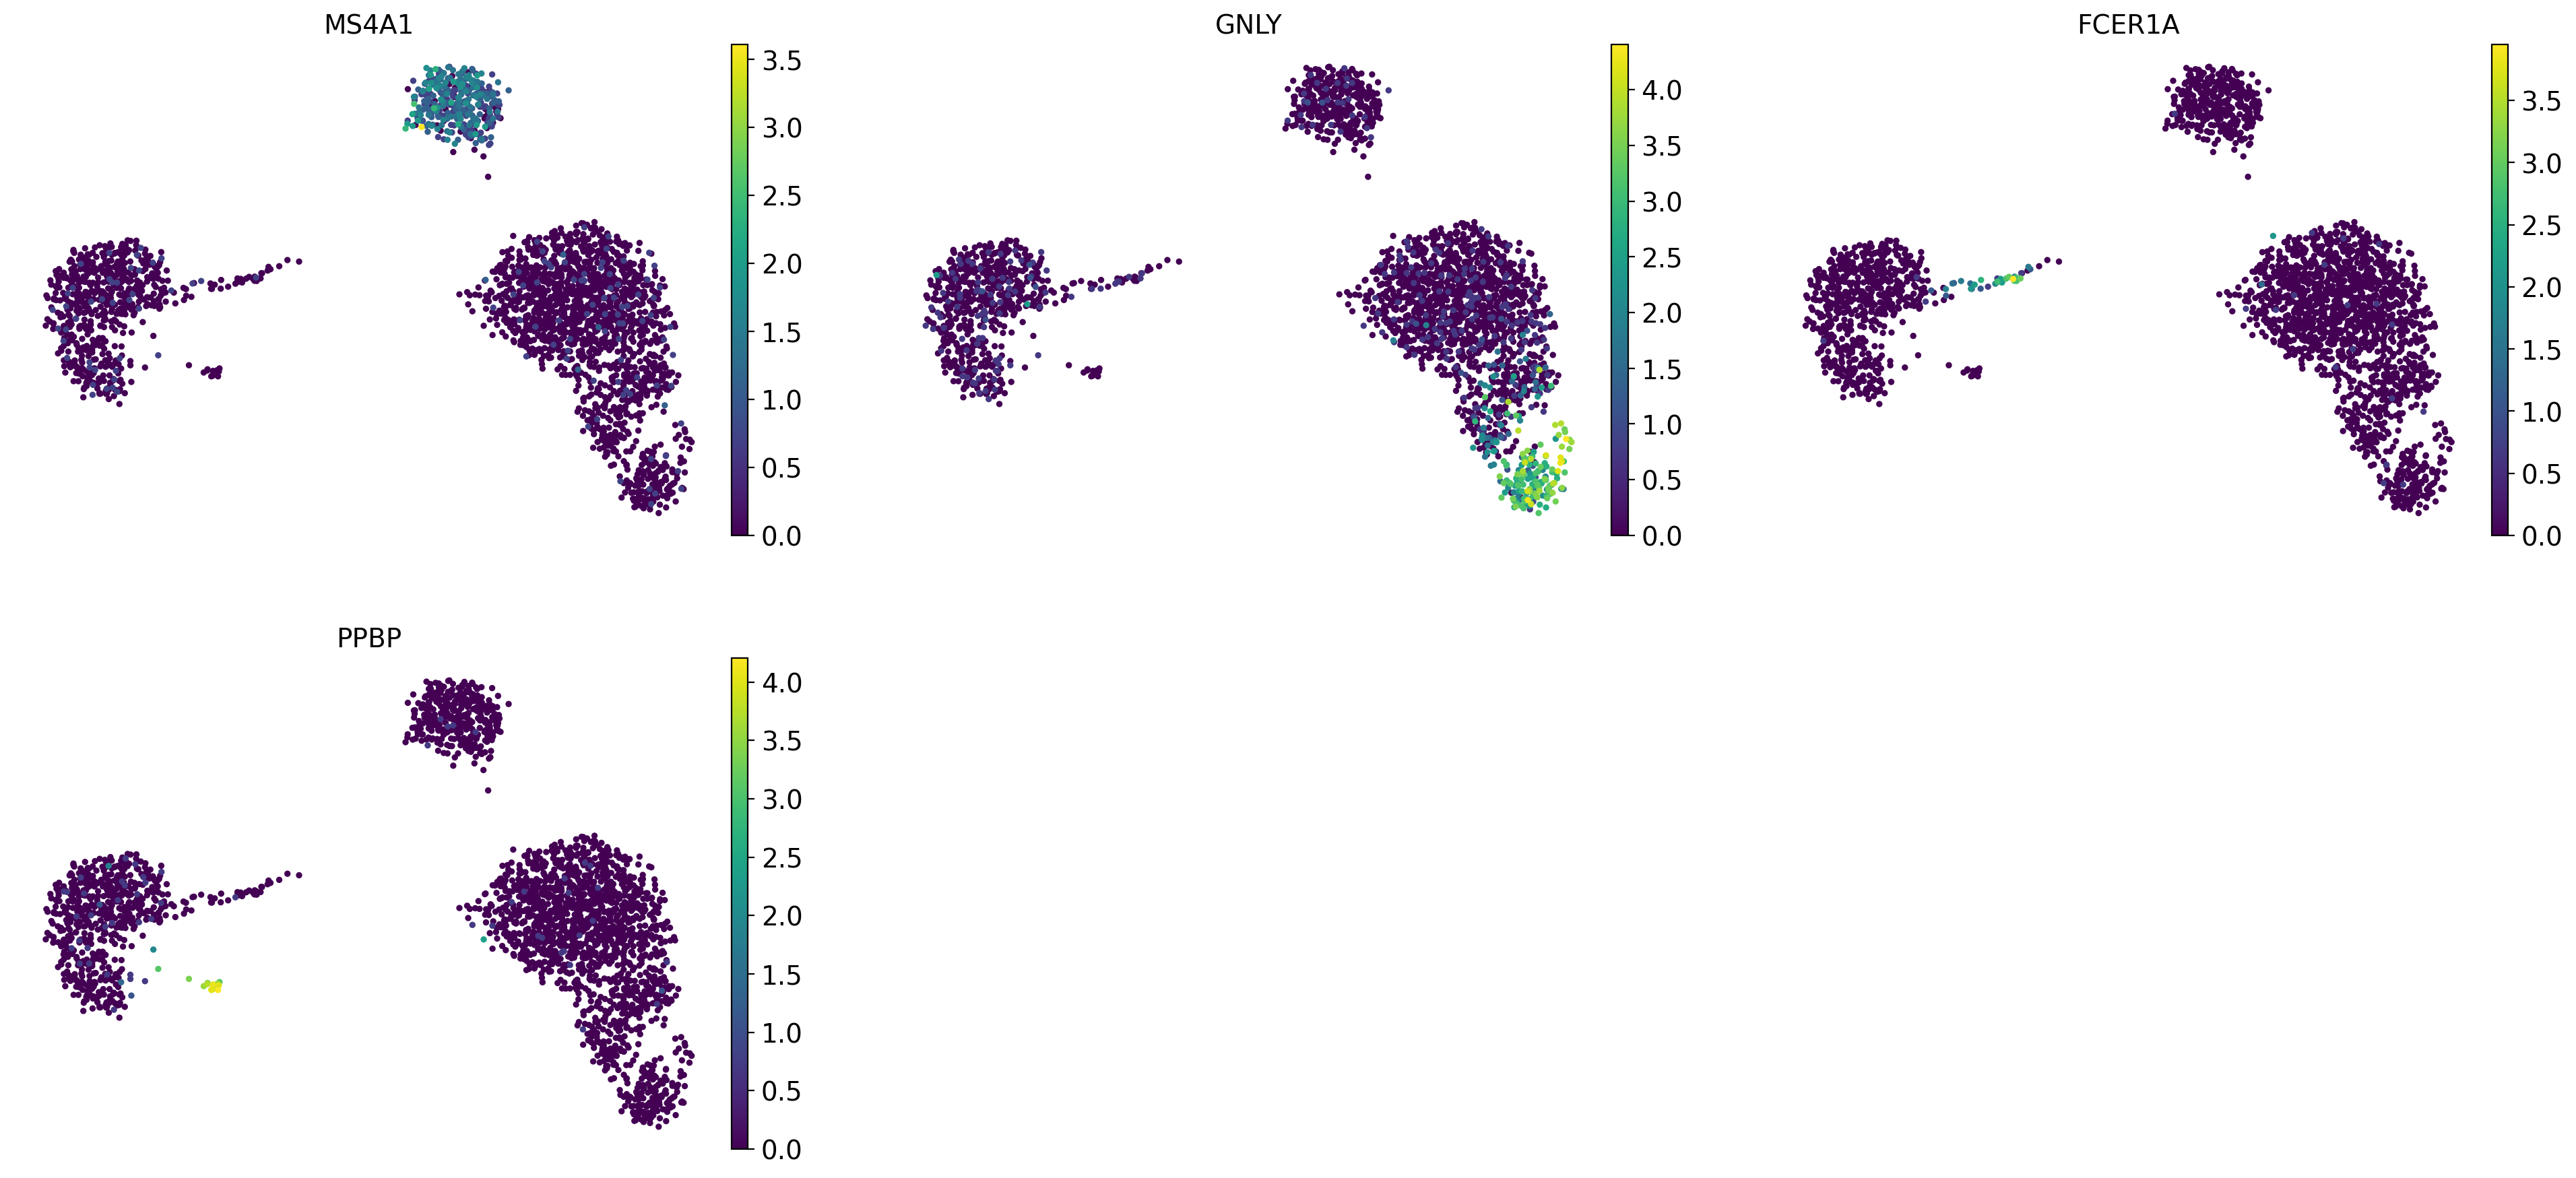

Marker gene UMAP plots saved.


In [12]:
# Known PBMC marker genes
marker_genes = [
    'IL7R',   # CD4 T cells
    'CD14',   # CD14 Monocytes
    'MS4A1',  # B cells
    'CD8A',   # CD8 T cells
    'GNLY',   # NK cells
    'FCER1A', # Dendritic cells
    'PPBP',   # Megakaryocytes
]

# Filter to genes present in this dataset
marker_genes = [g for g in marker_genes if g in adata.var_names]

sc.pl.umap(
    adata,
    color=marker_genes,
    ncols=3,
    frameon=False,
    save='_marker_genes_umap.png'
)
print('Marker gene UMAP plots saved.')

## Step 8 — Dot Plot of Marker Genes

This code generates a dot plot to visualize the expression levels and percentage of cells expressing your chosen marker_genes within each leiden cluster. In this visualization, the size of each dot represents the percentage of cells expressing the gene in that cluster, while the color intensity indicates the mean expression level.

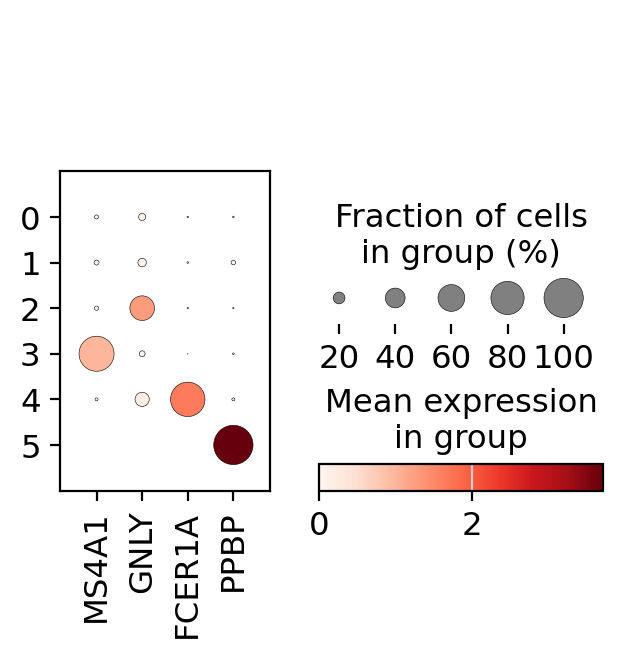

Dot plot saved.


In [13]:
sc.pl.dotplot(
    adata,
    marker_genes,
    groupby='leiden',
    save='_dotplot.png'
)
print('Dot plot saved.')

## Step 9 — Violin Plot of Marker Genes

This code creates a set of violin plots to visualize the distribution of expression levels for the first four marker genes across each Leiden cluster. The width and shape of each violin represent the probability density of gene expression, allowing you to see not just the average expression, but also how consistently a marker gene is expressed within a population.

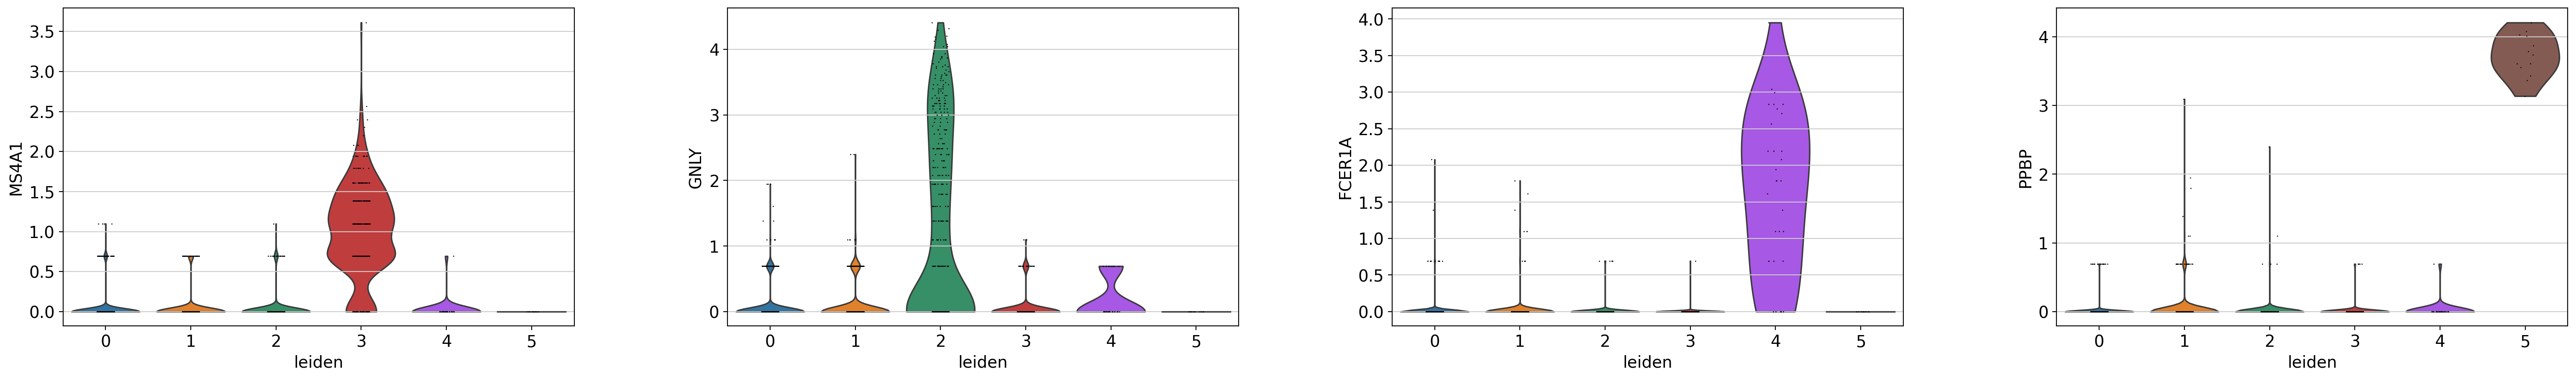

Violin plot saved.


In [14]:
sc.pl.violin(
    adata,
    marker_genes[:4],
    groupby='leiden',
    save='_violin_markers.png'
)
print('Violin plot saved.')

## Step 10 — Cell Type Annotation

This code maps your numerical Leiden cluster IDs to biological cell-type labels using a dictionary, creates a new cell_type category in your adata object, and saves a UMAP plot visualizing these annotated populations. This final step transitions your analysis from purely mathematical clusters to biologically meaningful cell types.

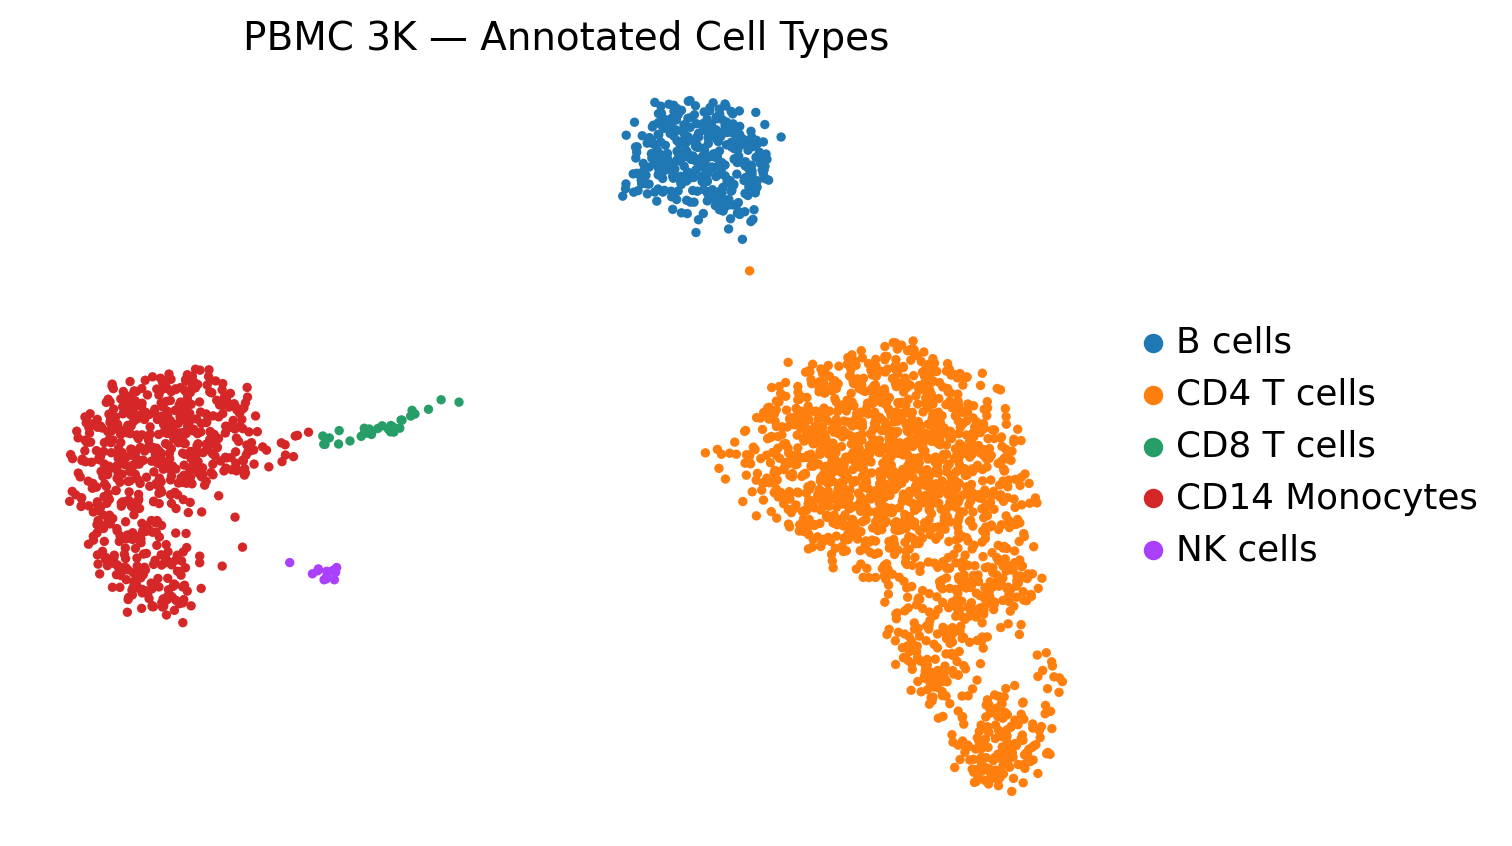

Cell type annotation complete.
cell_type
CD4 T cells       1615
CD14 Monocytes     638
B cells            341
CD8 T cells         31
NK cells            13
Name: count, dtype: int64


In [15]:
# Manual cell type annotation based on marker gene expression
# (Cluster IDs may vary — adjust based on your clustering results)
cell_type_map = {
    '0': 'CD4 T cells',
    '1': 'CD14 Monocytes',
    '2': 'CD4 T cells',
    '3': 'B cells',
    '4': 'CD8 T cells',
    '5': 'NK cells',
    '6': 'CD14 Monocytes',
    '7': 'Dendritic cells',
    '8': 'Megakaryocytes',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cell_type_map).fillna('Unknown')

sc.pl.umap(
    adata,
    color='cell_type',
    legend_loc='right margin',
    title='PBMC 3K — Annotated Cell Types',
    frameon=False,
    save='_cell_types.png'
)
print('Cell type annotation complete.')
print(adata.obs['cell_type'].value_counts())

## Step 11 — Save Final Annotated Data

In [16]:
adata.write_h5ad('pbmc3k_clustered.h5ad')
print('Annotated AnnData saved to: pbmc3k_clustered.h5ad')
print('\nFinal AnnData object:')
print(adata)

Annotated AnnData saved to: pbmc3k_clustered.h5ad

Final AnnData object:
AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain', 'leiden', 'cell_type'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'umap', 'leiden', 'leiden_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


---
## Summary

| Step | Method | Result |
|---|---|---|
| Neighborhood graph | k-NN (k=10, 40 PCs) | Cell connectivity map |
| UMAP | UMAP algorithm | 2D visualization |
| Clustering | Leiden (resolution=0.5) | ~9 distinct clusters |
| Marker genes | Wilcoxon rank-sum test | Top genes per cluster |
| Cell type annotation | Manual (known PBMC markers) | 7 cell types identified |

Results are used in **Task 3 — AnnData Tutorial** for structured data exploration.